In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Preparation

# Write a python program to load data into pandas Data Frame and display last 50 records

In [4]:
df = pd.read_csv('ids.csv')
df.tail(50)

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


# Write a Python program to create a separate Data Frame containing only the following columns list for further analysis.
columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 'Packet Length Std', 'Average Packet Size', 'Active Mean', 'Idle Mean', 'Label']

In [5]:
columns = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Total Length of Fwd Packets',
    'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
    'Active Mean', 'Idle Mean', 'Label'
]

df_selected = df[columns]

print(df_selected.head())

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0                53          62171                  2                       2   
1              2710             48                  2                       0   
2               443        4792909                  5                       1   
3                80      115596470                 75                      82   
4              2910             14                  2                       2   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           78                          164   
1                            4                            0   
2                          135                           46   
3                          342                       118155   
4                            4                           12   

   Fwd Packet Length Mean  Bwd Packet Length Mean  Flow Bytes/s  \
0                   39.00               82.000000  3.892490e+03   


# Write a Python program to check for NaN (missing values) and remove them from the newly created DataFrame

In [6]:
# check missing values
print(df_selected.isnull().sum())

# remove rows with NaN values
df_clean = df_selected.dropna()

print(df_clean)

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64
        Destination Port  Flow Duration  Total Fwd Packets  \
0                     53          62171                  2   
1                   2710             48                  2   
2                    443        4792909                  5   
3                     80      115596470                 75   
4                   2910             14                  2   
...                  ...            ...                ...   
488110   

# Write a python program to check if duplicated records exist and find their total number.

In [7]:
# find duplicated rows
duplicates = df_clean.duplicated()

# count total duplicates
print("Total duplicated records:", duplicates.sum())

Total duplicated records: 139389


# Write a python program to show total number of columns. Also display name of all columns.

In [8]:
print("Total number of columns:", df.shape[1])


print("Column names: ")
print(df.columns)

Total number of columns: 80
Column names: 
Index(['Unnamed: 0', 'Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packe

# Rename the values in the Label column as follows:
o BENIGN – Normal Traffic

o Infiltration – Attack

In [9]:
df['Label'] = df['Label'].replace({
    'BENIGN': 'Normal Traffic',
    'Infiltration': 'Attack'
})


print(df['Label'].value_counts())

Label
Normal Traffic    288566
Attack            199549
Name: count, dtype: int64


# Data Analysis

# Write a Python program to show summary statistics of sum, mean, standard deviation, skewness, and kurtosis of any 2 chosen numeric variable.


In [10]:
cols = ['Flow Duration', 'Packet Length Mean']

# calculate statistics
print("Sum:\n", df[cols].sum())
print("\nMean:\n", df[cols].mean())
print("\nStandard Deviation:\n", df[cols].std())
print("\nSkewness:\n", df[cols].skew())
print("\nKurtosis:\n", df[cols].kurt())

Sum:
 Flow Duration         4.364853e+12
Packet Length Mean    4.175763e+07
dtype: float64

Mean:
 Flow Duration         8.942263e+06
Packet Length Mean    8.554875e+01
dtype: float64

Standard Deviation:
 Flow Duration         2.748091e+07
Packet Length Mean    1.738676e+02
dtype: float64

Skewness:
 Flow Duration         3.251026
Packet Length Mean    4.935916
dtype: float64

Kurtosis:
 Flow Duration          9.247816
Packet Length Mean    34.612664
dtype: float64


# Write a Python program to calculate and show correlation of all numeric variables. Display top 5 correlated feature.

In [11]:
# correlation matrix
corr = df.corr(numeric_only=True)

print("Correlation Matrix: ")
print(corr)

# find top 5 correlated feature pairs
top_corr = corr.unstack().sort_values(ascending=False)

# remove self correlations
top_corr = top_corr[top_corr < 1]

print("\nTop 5 Correlated Features:")
print(top_corr.head(5))

Correlation Matrix: 
                        Unnamed: 0  Destination Port  Flow Duration  \
Unnamed: 0                1.000000          0.000528       0.000318   
Destination Port          0.000528          1.000000      -0.145257   
Flow Duration             0.000318         -0.145257       1.000000   
Total Fwd Packets        -0.000550         -0.025713       0.124345   
Total Backward Packets   -0.000877         -0.024030       0.100837   
...                            ...               ...            ...   
Active Min                0.000368         -0.037289       0.107845   
Idle Mean                -0.000459         -0.109353       0.653140   
Idle Std                 -0.001214         -0.031711       0.191380   
Idle Max                 -0.000638         -0.109888       0.656950   
Idle Min                 -0.000270         -0.105967       0.628961   

                        Total Fwd Packets  Total Backward Packets  \
Unnamed: 0                      -0.000550               -

# Data Exploration

# Plot a bar chart showing the frequency of each category in the Label column (with values as Normal Traffic and Attack). Determine whether the Label, as the dependent variable, is balanced or not in the dataset.Provide an analysis

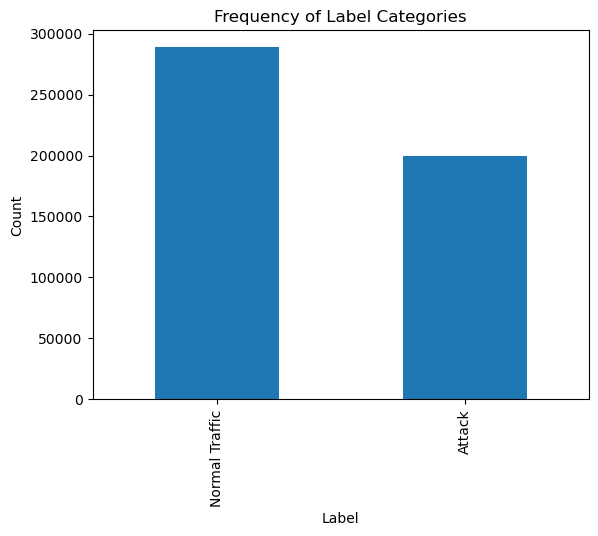

In [12]:
label_counts = df['Label'].value_counts()

label_counts.plot(kind='bar')
plt.title("Frequency of Label Categories")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Analysis
The dataset is not balanced.

Normal Traffic has more samples than Attack.

However, the difference is moderate, so it is slightly imbalanced, not severely skewed.

# Determine which category in the Label column (with values as Normal Traffic and Attack) has the highest average Flow Duration and the highest average Packet Length Mean. Visualize these findings with pie chart

                Flow Duration  Packet Length Mean
Label                                            
Attack           8.908243e+06           85.565536
Normal Traffic   8.965789e+06           85.537144


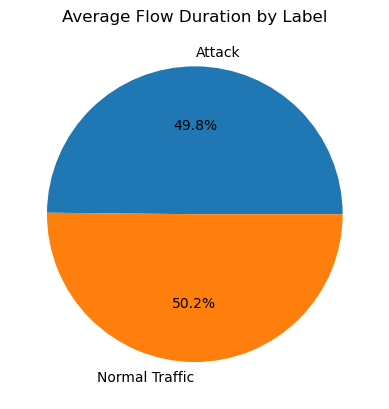

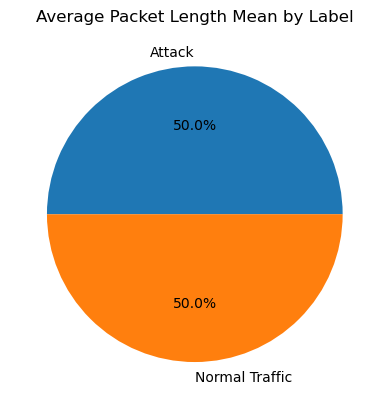

In [13]:
avg_values = df.groupby('Label')[['Flow Duration', 'Packet Length Mean']].mean()

print(avg_values)

# pie chart for Flow Duration
avg_values['Flow Duration'].plot(kind='pie', autopct='%1.1f%%')
plt.title("Average Flow Duration by Label")
plt.ylabel("")
plt.show()

# pie chart for Packet Length Mean
avg_values['Packet Length Mean'].plot(kind='pie', autopct='%1.1f%%')
plt.title("Average Packet Length Mean by Label")
plt.ylabel("")
plt.show()

# Interpretation:
Flow Duration: Almost equal, but Normal Traffic is slightly higher.

Packet Length Mean: Attack is slightly higher.

Pie charts show 50%-50% contribution, meaning differences are minimal.

# Generate boxplot of 'Fwd Packet Length Mean' grouped by the Label column to visualize the distribution for each attack type and normal traffic. Analyse the differences across these categories.

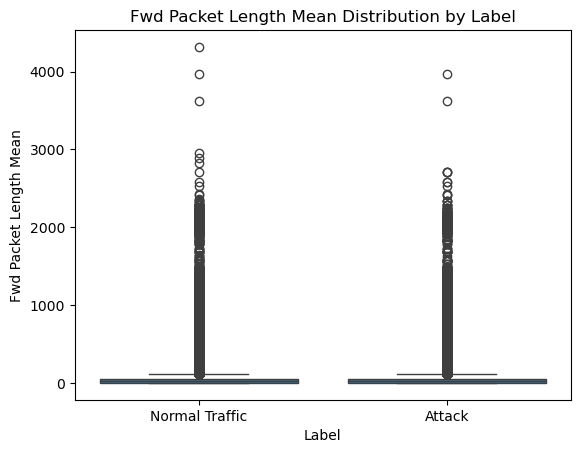

In [14]:
sns.boxplot(x='Label', y='Fwd Packet Length Mean', data=df)
plt.title("Fwd Packet Length Mean Distribution by Label")
plt.show()

# Analysis:

Both classes have very similar median and spread.

Large number of outliers in both categories.

No clear separation therefore, this feature alone cannot distinguish Attack vs Normal Traffic effectively.

# Perform a hypothesis test to determine if there is a significant difference in the mean Flow Duration between Normal Traffic and Attack classes. State your null and alternative hypotheses, choose an appropriate test, perform it, and interpret the results.

In [15]:

normal = df[df['Label'] == 'Normal Traffic']['Flow Duration']
attack = df[df['Label'] == 'Attack']['Flow Duration']

t_stat, p_value = stats.ttest_ind(normal, attack)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.7192383256237452
P-value: 0.47199443329085733


# Hypotheses:

H₀: Mean Flow Duration (Normal) = Mean Flow Duration (Attack)
H₁: Means are different

#  Analysis

Since p-value (0.472) > 0.05, we fail to reject H₀.
    
There is no significant difference in Flow Duration between the two classes.